#### Imports

In [78]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import copy
import random
import os
from pathlib import Path
import pandas as pd
import time
import itertools
import re

from tqdm import tqdm
from collections import defaultdict
import torch
from torchinfo import summary as info_summary
from torchsummary import summary as sum_summary
import pickle

import globals
import utils
import nn_dataset
import nn_models

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

Current device: cuda


In [79]:
importlib.reload(globals)
importlib.reload(utils)
importlib.reload(nn_dataset)
importlib.reload(nn_models)

<module 'nn_models' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Masters_Thesis\\nn_models.py'>

In [80]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [81]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

X_tr, X_val, X_test, Y_tr, Y_val, Y_test = utils.train_val_test_split(X, Y_resh, wavelengths, verbose=True)

X shape: (500, 9)
Y shape: (500, 6, 4205)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (50, 9)
X_test shape: (50, 9)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)


#### Neural Network Pipeline

<ol>
    <li><b>Model and Dataset Definition</b>: Encoder-Decoder architectures.</li>
    <li><b>Training/Validation</b>: train loop with validation to choose the best model.</li>
    <li><b>External Testing</b> of the best selected model.</li>
</ol>

In [82]:
# quick model test
model = nn_models.EmulatorSet1(encoder_type="single").to(device)
model.eval()

# dummy input: (batch_size, 9)
X_tr_tensor = torch.randn(400, 9, dtype=torch.float32).to(device)
print("Input shape:", X_tr_tensor.shape)

with torch.no_grad():
    y_pred = model(X_tr_tensor)

# y is a tensor of shape (N, 6, 4205)
print("Output shape:", y_pred.shape)

info_summary(model, input_size=(1, globals.N_INPUTS))

Input shape: torch.Size([400, 9])
Output shape: torch.Size([400, 6, 4205])


Layer (type:depth-idx)                        Output Shape              Param #
EmulatorSet1                                  [1, 6, 4205]              --
├─Encoder: 1-1                                [1, 128]                  --
│    └─Sequential: 2-1                        [1, 128]                  --
│    │    └─Linear: 3-1                       [1, 64]                   640
│    │    └─SiLU: 3-2                         [1, 64]                   --
│    │    └─Linear: 3-3                       [1, 128]                  8,320
│    │    └─SiLU: 3-4                         [1, 128]                  --
│    │    └─Linear: 3-5                       [1, 128]                  16,512
│    │    └─SiLU: 3-6                         [1, 128]                  --
├─ModuleList: 1-2                             --                        --
│    └─SpectralDecoder1: 2-2                  [1, 4205]                 --
│    │    └─Linear: 3-7                       [1, 512]                  66,048
│    │  

Investigate scaled datasets.

In [83]:
# scaled outputs
y_scalers, Y_tr_scaled, Y_val_scaled = utils.scale_output_data(Y_tr, Y_val, scale_type="minmax")

print("Train scaled min:", Y_tr_scaled.min())
print("Val scaled min:", Y_val_scaled.min())

print(np.sum(Y_tr_scaled == 0))
print(np.sum(Y_val_scaled == 0))

---------- Scaling output data using minmax scaling... ----------
---------- Output data scaling completed. ----------

Train scaled min: 0.0
Val scaled min: -0.16481781
103253
9799


Using MRE as the loss function in this scenario would not be desirable, as the training loss would explode to very high values due to the high amount of training values near zero. Scaled or reduced data has many values that are zero or near zero, which would make the MRE explode. Using a wavelength mask would exclude deep absorption bands, but the MRE would still be calculated on the scaled and reduced data, which would not solve the exploding problem. MRE calculated on the restored data could be used as loss, but it would not be a meaningful objective, as it would be calculated on data that is fundamentally different from what the model actually sees.

In [84]:
# ==================== EXPERIMENT GRID ====================
ARCHITECTURES = {
    "EmulatorSet1": nn_models.EmulatorSet1,
    "EmulatorSet2": nn_models.EmulatorSet2,
    "EmulatorSet3": nn_models.EmulatorSet3,
    "EmulatorSet4": nn_models.EmulatorSet4,
}

ENCODER_VERSIONS = [
    "single", 
    "multi",
]

SCALE_TYPES = [
    "minmax", 
    "standard",
]

# which model families use the full dataset vs. the reduced one
FULL_DS_MODELS    = {"EmulatorSet1"}
REDUCED_DS_MODELS = {"EmulatorSet2", "EmulatorSet3", "EmulatorSet4"}

BATCH_SIZE = 64
N_EPOCHS = 100
PATIENCE = 25

In [85]:
def create_datasets(X_tr, X_val, Y_tr, Y_val, X_test, Y_test, verbose=True):
    train_ds = nn_dataset.MyDataset(X_tr, Y_tr)
    val_ds = nn_dataset.MyDataset(X_val, Y_val)
    test_ds = nn_dataset.MyDataset(X_test, Y_test)

    if verbose:
        print("Train dataset length:", len(train_ds))
        print("Val dataset length:", len(val_ds))
        print("Test dataset length:", len(test_ds))

        # get item check
        x, y = train_ds.__getitem__(0)
        print("Input shape:", x.shape)
        print("Output shape:", y.shape)
        print()

    return train_ds, val_ds, test_ds


def prepare_all_experiments(X_tr, X_val, X_test, Y_tr, Y_val, Y_test, n_pca_components=10):
    config = {
        "x_scalers":               {},
        "y_scalers":               {},
        "y_scalers_reduced":       {},
        "pca_lists":               {},
        "train_ds_scaled":         {},
        "val_ds_scaled":           {},
        "test_ds_scaled":          {},
        "train_ds_reduced_scaled": {},
        "val_ds_reduced_scaled":   {},
        "test_ds_reduced_scaled":  {},
    }

    # PCA is fit on raw outputs — independent of scale type, so compute once
    pca_list, Y_tr_reduced, Y_val_reduced = utils.apply_pca(Y_tr, Y_val, n_components=n_pca_components)
    Y_test_reduced = np.zeros((Y_test.shape[0], globals.N_FUNCTIONS, n_pca_components))
    for i in range(globals.N_FUNCTIONS):
        Y_test_reduced[:, i, :] = pca_list[i].transform(Y_test[:, i, :])

    for scale_type in SCALE_TYPES:
        print(f"\n── Preparing [{scale_type}] ──────────────────────────────")

        # --- inputs ---
        x_scaler, X_tr_scaled, X_val_scaled = utils.scale_input_data(
            X_tr, X_val, scale_type=scale_type
        )
        X_test_scaled = x_scaler.transform(X_test)

        # --- full outputs ---
        y_scalers, Y_tr_scaled, Y_val_scaled = utils.scale_output_data(
            Y_tr, Y_val, scale_type=scale_type
        )
        Y_test_scaled = np.zeros_like(Y_test)
        for i in range(globals.N_FUNCTIONS):
            Y_test_scaled[:, i, :] = y_scalers[i].transform(Y_test[:, i, :])

        # --- reduced outputs ---
        y_scalers_reduced, Y_tr_reduced_scaled, Y_val_reduced_scaled = utils.scale_output_data(
            Y_tr_reduced, Y_val_reduced, scale_type=scale_type
        )
        Y_test_reduced_scaled = np.zeros((Y_test.shape[0], globals.N_FUNCTIONS, n_pca_components))
        for i in range(globals.N_FUNCTIONS):
            Y_test_reduced_scaled[:, i, :] = y_scalers_reduced[i].transform(Y_test_reduced[:, i, :])

        # --- datasets ---
        train_ds_scaled, val_ds_scaled, test_ds_scaled = create_datasets(
            X_tr_scaled, X_val_scaled, Y_tr_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled
        )
        train_ds_reduced_scaled, val_ds_reduced_scaled, test_ds_reduced_scaled = create_datasets(
            X_tr_scaled, X_val_scaled, Y_tr_reduced_scaled, Y_val_reduced_scaled,
            X_test_scaled, Y_test_reduced_scaled
        )

        # --- store everything under the scale_type key ---
        config["x_scalers"][scale_type]               = x_scaler
        config["y_scalers"][scale_type]               = y_scalers
        config["y_scalers_reduced"][scale_type]       = y_scalers_reduced
        config["pca_lists"][scale_type]               = pca_list        # same for both
        config["train_ds_scaled"][scale_type]         = train_ds_scaled
        config["val_ds_scaled"][scale_type]           = val_ds_scaled
        config["test_ds_scaled"][scale_type]          = test_ds_scaled
        config["train_ds_reduced_scaled"][scale_type] = train_ds_reduced_scaled
        config["val_ds_reduced_scaled"][scale_type]   = val_ds_reduced_scaled
        config["test_ds_reduced_scaled"][scale_type]  = test_ds_reduced_scaled

    # training hyperparameters
    config["batch_size"] = BATCH_SIZE
    config["n_epochs"]   = N_EPOCHS
    config["patience"]   = PATIENCE

    return config


# ==================== DATASET / SCALER ROUTER ====================
def get_loaders_and_scalers(model_name, scale_type, config):
    """Return (train_dl, val_dl, y_scalers) for a given experiment."""
    if model_name in FULL_DS_MODELS:
        train_ds = config["train_ds_scaled"][scale_type]
        val_ds   = config["val_ds_scaled"][scale_type]
        y_scalers = config["y_scalers"][scale_type]
        pca_list = None
    else:
        train_ds = config["train_ds_reduced_scaled"][scale_type]
        val_ds   = config["val_ds_reduced_scaled"][scale_type]
        y_scalers = config["y_scalers_reduced"][scale_type]
        pca_list = config["pca_lists"][scale_type]

    train_dl = torch.utils.data.DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)
    val_dl   = torch.utils.data.DataLoader(val_ds,   batch_size=config["batch_size"], shuffle=False)
    return train_ds, val_ds, train_dl, val_dl, y_scalers, pca_list


def calculate_metrics(y_pred, Y_batch, wavelengths, y_scalers, pca_list):
    is_scaled  = y_scalers is not None
    is_reduced = pca_list  is not None

    if is_scaled or is_reduced:
        # prepare tensors to hold the restored predictions and targets in original space
        y_pred_og_shape = torch.zeros((y_pred.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=y_pred.device)
        y_true_og_shape = torch.zeros((Y_batch.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=Y_batch.device)

        # inverse transform the scaling and PCA to get back to original space if needed
        for i in range(globals.N_FUNCTIONS):
            y_pred_restored = y_pred[:, i, :].cpu().detach().numpy()
            y_true_restored = Y_batch[:, i, :].cpu().detach().numpy()
            if is_scaled:
                y_pred_restored = y_scalers[i].inverse_transform(y_pred_restored)
                y_true_restored = y_scalers[i].inverse_transform(y_true_restored)
            if is_reduced:
                y_pred_restored = pca_list[i].inverse_transform(y_pred_restored)
                y_true_restored = pca_list[i].inverse_transform(y_true_restored)
            y_pred_og_shape[:, i, :] = torch.from_numpy(y_pred_restored).to(y_pred_og_shape.device)
            y_true_og_shape[:, i, :] = torch.from_numpy(y_true_restored).to(y_true_og_shape.device)

        batch_train_mre_unscaled = utils.mre_score(y_true_og_shape.cpu().detach().numpy(), y_pred_og_shape.cpu().detach().numpy(), wavelengths)
        batch_train_mae_unscaled = utils.mae_score(y_true_og_shape.cpu().detach().numpy(), y_pred_og_shape.cpu().detach().numpy(), wavelengths)
    else:
        batch_train_mre_unscaled = utils.mre_score(Y_batch.cpu().detach().numpy(), y_pred.cpu().detach().numpy(), wavelengths)
        batch_train_mae_unscaled = utils.mae_score(Y_batch.cpu().detach().numpy(), y_pred.cpu().detach().numpy(), wavelengths)

    return batch_train_mre_unscaled, batch_train_mae_unscaled


# ==================== SINGLE EXPERIMENT ====================
def run_experiment(model_name, encoder_version, scale_type, config, device, wavelengths):
    dataset_size = int(re.search(r'\d+', Path(globals.CURRENT_TRAIN_FILE).stem).group())
    exp_id = f"{model_name}_{encoder_version}_{scale_type}_{dataset_size}"
    print(f"\n{'='*60}")
    print(f"  EXPERIMENT: {exp_id}")
    print(f"{'='*60}")

    # --- build model ---
    ModelClass = ARCHITECTURES[model_name]
    model = ModelClass(encoder_type=encoder_version).to(device)

    # --- data ---
    train_ds, val_ds, train_dl, val_dl, y_scalers, pca_list = get_loaders_and_scalers(
        model_name, scale_type, config
    )

    # --- optimiser / loss / scheduler ---
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.L1Loss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.2, patience=5
    )

    # --- early stopping state ---
    n_epochs        = config.get("n_epochs", 100)
    patience        = config.get("patience", 25)
    best_val_mre    = float("inf")
    patience_counter = 0
    best_model_wts  = copy.deepcopy(model.state_dict())
    history         = defaultdict(list)

    start_time = time.time()

    for epoch in range(n_epochs):
        # ---------- TRAIN ----------
        model.train()
        epoch_train_loss = epoch_train_mre = epoch_train_mae = 0.0
        # accumulate preds and targets to compute metrics once at the end of the loop to avoid aggregation artifacts
        all_preds   = []
        all_targets = []

        for X_batch, Y_batch in tqdm(train_dl, desc=f"[{exp_id}] E{epoch+1} Train", leave=False):
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = criterion(y_pred, Y_batch)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item() * X_batch.size(0)
            all_preds.append(y_pred.detach().cpu())
            all_targets.append(Y_batch.cpu())

        all_preds   = torch.cat(all_preds,   dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        epoch_train_mre, epoch_train_mae = calculate_metrics(all_preds, all_targets, wavelengths, y_scalers, pca_list)
        epoch_train_loss /= len(train_ds)

        # ---------- VALIDATE ----------
        model.eval()
        epoch_val_loss = epoch_val_mre = epoch_val_mae = 0.0
        all_preds   = []
        all_targets = []

        with torch.no_grad():
            for X_batch, Y_batch in tqdm(val_dl, desc=f"[{exp_id}] E{epoch+1} Val", leave=False):
                X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
                y_pred = model(X_batch)
                loss   = criterion(y_pred, Y_batch)

                epoch_val_loss += loss.item() * X_batch.size(0)
                all_preds.append(y_pred.cpu())
                all_targets.append(Y_batch.cpu())

        all_preds   = torch.cat(all_preds,   dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        epoch_val_mre, epoch_val_mae = calculate_metrics(all_preds, all_targets, wavelengths, y_scalers, pca_list)
        epoch_val_loss /= len(val_ds)

        scheduler.step(epoch_val_mre)

        # record
        history["train_loss"].append(epoch_train_loss)
        history["train_mre"].append(epoch_train_mre)
        history["train_mae"].append(epoch_train_mae)
        history["val_loss"].append(epoch_val_loss)
        history["val_mre"].append(epoch_val_mre)
        history["val_mae"].append(epoch_val_mae)

        print(
            f"  E{epoch+1:03d} | "
            f"train loss {epoch_train_loss:.5f}  mre {epoch_train_mre:.5f}  mae {epoch_train_mae:.5f} | "
            f"val loss {epoch_val_loss:.5f}  mre {epoch_val_mre:.5f}  mae {epoch_val_mae:.5f}"
        )

        # ---------- EARLY STOPPING ----------
        if epoch_val_mre < best_val_mre:
            best_val_mre   = epoch_val_mre
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print("  --> best val MRE — weights saved")
        else:
            patience_counter += 1
            print(f"  --> no improvement ({patience_counter}/{patience})")
            if patience_counter >= patience:
                print("  !!! early stopping !!!")
                break

    elapsed = time.time() - start_time

    # reload best weights
    model.load_state_dict(best_model_wts)

    # persist model
    os.makedirs("nn_saves", exist_ok=True)
    torch.save(model.state_dict(), f"nn_saves/model_saves/{exp_id}.pth")

    # save history
    with open(f"nn_saves/model_saves/{exp_id}_history.pkl", "wb") as f:
        pickle.dump(history, f)

    # build result row
    idx_best = int(np.argmin(history["val_mre"]))
    result = {
        "experiment_id":  exp_id,
        "model":          model_name,
        "encoder":        encoder_version,
        "scale_type":     scale_type,
        "dataset_size":   dataset_size,
        "fit_time":       elapsed,
        "best_epoch":     idx_best + 1,
        "best_train_loss": history["train_loss"][idx_best],
        "best_val_loss":   history["val_loss"][idx_best],
        "best_train_mre":  history["train_mre"][idx_best],
        "best_val_mre":    history["val_mre"][idx_best],
        "best_train_mae":  history["train_mae"][idx_best],
        "best_val_mae":    history["val_mae"][idx_best],
    }
    return model, history, result


# ==================== FULL EXPERIMENT LOOP ====================
def run_all_experiments(config, device, wavelengths):
    results_path = Path("nn_saves/nn_results.csv")
    all_results  = []

    grid = list(itertools.product(ARCHITECTURES.keys(), ENCODER_VERSIONS, SCALE_TYPES))
    print(f"Total experiments to run: {len(grid)}")

    for model_name, encoder_version, scale_type in grid:
        try:
            model, history, result = run_experiment(
                model_name, encoder_version, scale_type,
                config, device, wavelengths
            )
            all_results.append(result)

            # append to CSV after every experiment so a crash doesn't lose data
            row_df = pd.DataFrame([result])
            row_df.to_csv(
                results_path,
                mode="a",
                header=not results_path.exists(),
                index=False,
            )
            print(f"  Saved results for {result['experiment_id']}\n")

        except Exception as e:
            print(f"  [ERROR] {model_name}__{encoder_version}__{scale_type} failed: {e}")
            continue

    summary = pd.DataFrame(all_results).sort_values("best_val_mre")
    print("\n===== EXPERIMENT SUMMARY (sorted by val MRE) =====")
    print(summary[["experiment_id", "best_val_mre", "best_val_mae", "best_epoch", "fit_time"]].to_string(index=False))
    return summary, model, history

In [86]:
config = prepare_all_experiments(X_tr, X_val, X_test, Y_tr, Y_val, Y_test)

---------- Applying PCA with n_components=10 to each function separately... ----------
  Regular PCA used, displaying results:
  Function 1: Explained variance = 1.0000
  Number of components retained: 10

  Function 2: Explained variance = 1.0000
  Number of components retained: 10

  Function 3: Explained variance = 1.0000
  Number of components retained: 10

  Function 4: Explained variance = 0.9999
  Number of components retained: 10

  Function 5: Explained variance = 1.0000
  Number of components retained: 10

  Function 6: Explained variance = 1.0000
  Number of components retained: 10

  Total explained variance = 5.9999
---------- PCA application completed. ----------


── Preparing [minmax] ──────────────────────────────
---------- Scaling input data using minmax scaling... ----------
---------- Input data scaling completed. ----------

---------- Scaling output data using minmax scaling... ----------
---------- Output data scaling completed. ----------

---------- Scaling ou

In [36]:
# ============================== !!CRITICAL CELL!! ==============================

summary, last_model, last_history = run_all_experiments(config, device, wavelengths)

Total experiments to run: 1

  EXPERIMENT: EmulatorSet5_multi_standard_500


  E001 | train loss 0.81712  mre 0.20971  mae 28.44724 | val loss 0.87167  mre 0.25112  mae 30.25899
  --> best val MRE — weights saved


  E002 | train loss 0.80639  mre 0.20808  mae 27.58144 | val loss 0.86646  mre 0.25429  mae 29.26792
  --> no improvement (1/25)


  E003 | train loss 0.78857  mre 0.20528  mae 26.17806 | val loss 0.85005  mre 0.23176  mae 28.32472
  --> best val MRE — weights saved


  E004 | train loss 0.76938  mre 0.19777  mae 26.23444 | val loss 0.85430  mre 0.23106  mae 29.75146
  --> best val MRE — weights saved


...

  E096 | train loss 0.18938  mre 0.03709  mae 2.95214 | val loss 0.18776  mre 0.03671  mae 3.23099
  --> best val MRE — weights saved


  E097 | train loss 0.18933  mre 0.03711  mae 2.94926 | val loss 0.18815  mre 0.03687  mae 3.24831
  --> no improvement (1/25)


  E098 | train loss 0.18925  mre 0.03709  mae 2.94976 | val loss 0.18773  mre 0.03674  mae 3.21429
  --> no improvement (2/25)


  E099 | train loss 0.18913  mre 0.03709  mae 2.94649 | val loss 0.18768  mre 0.03676  mae 3.22992
  --> no improvement (3/25)


  E100 | train loss 0.18905  mre 0.03705  mae 2.94087 | val loss 0.18770  mre 0.03673  mae 3.22962
  --> no improvement (4/25)
  Saved results for EmulatorSet5_multi_standard_500


===== EXPERIMENT SUMMARY (sorted by val MRE) =====
                  experiment_id  best_val_mre  best_val_mae  best_epoch   fit_time
EmulatorSet5_multi_standard_500      0.036708      3.230989          96 243.282923


In [18]:
summary

,experiment_id,model,encoder,scale_type,dataset_size,fit_time,best_epoch,best_train_loss,best_val_loss,best_train_mre,best_val_mre,best_train_mae,best_val_mae
8,EmulatorSet3_single_minmax_10000,EmulatorSet3,single,minmax,10000,793.746402,96,0.002185,0.002164,0.000950,0.000969,0.111073,0.111109
13,EmulatorSet4_single_standard_10000,EmulatorSet4,single,standard,10000,605.449314,100,0.019993,0.019780,0.001033,0.001071,0.129294,0.132132
10,EmulatorSet3_multi_minmax_10000,EmulatorSet3,multi,minmax,10000,805.632896,98,0.002316,0.002294,0.001094,0.001115,0.121058,0.119053
5,EmulatorSet2_single_standard_10000,EmulatorSet2,single,standard,10000,580.186641,98,0.019770,0.019546,0.001122,0.001143,0.136631,0.138685
11,EmulatorSet3_multi_standard_10000,EmulatorSet3,multi,standard,10000,804.360499,96,0.017508,0.017574,0.001161,0.001238,0.144344,0.153114
15,EmulatorSet4_multi_standard_10000,EmulatorSet4,multi,standard,10000,632.977189,94,0.020753,0.020484,0.001227,0.001273,0.155539,0.156810
9,EmulatorSet3_single_standard_10000,EmulatorSet3,single,standard,10000,796.381909,97,0.018637,0.018710,0.001233,0.001311,0.151798,0.161039
14,EmulatorSet4_multi_minmax_10000,EmulatorSet4,multi,minmax,10000,632.440834,79,0.002761,0.002695,0.001456,0.001474,0.163270,0.159235
7,EmulatorSet2_multi_standard_10000,EmulatorSet2,multi,standard,10000,607.487307,100,0.021944,0.021594,0.001495,0.001525,0.181377,0.183825
12,EmulatorSet4_single_minmax_10000,EmulatorSet4,single,minmax,10000,606.511677,97,0.002797,0.002743,0.001511,0.001547,0.162551,0.159867


#### Analysis of Validation Results

Average Fit Time by Dataset Size
 dataset_size  avg_fit_time
          500    111.891453
         2000    195.761592
        10000    728.191658

Average Best Val MRE by Dataset Size & Model
 dataset_size        model  avg_best_val_mre
          500 EmulatorSet1          0.007801
          500 EmulatorSet2          0.005822
          500 EmulatorSet3          0.007190
          500 EmulatorSet4          0.005671
         2000 EmulatorSet1          0.006230
         2000 EmulatorSet2          0.002889
         2000 EmulatorSet3          0.002675
         2000 EmulatorSet4          0.002516
        10000 EmulatorSet1          0.004820
        10000 EmulatorSet2          0.001686
        10000 EmulatorSet3          0.001158
        10000 EmulatorSet4          0.001341

Average Best Val MAE by Dataset Size & Model
 dataset_size        model  avg_best_val_mae
          500 EmulatorSet1          0.810456
          500 EmulatorSet2          0.660718
          500 EmulatorSet3          0.82942

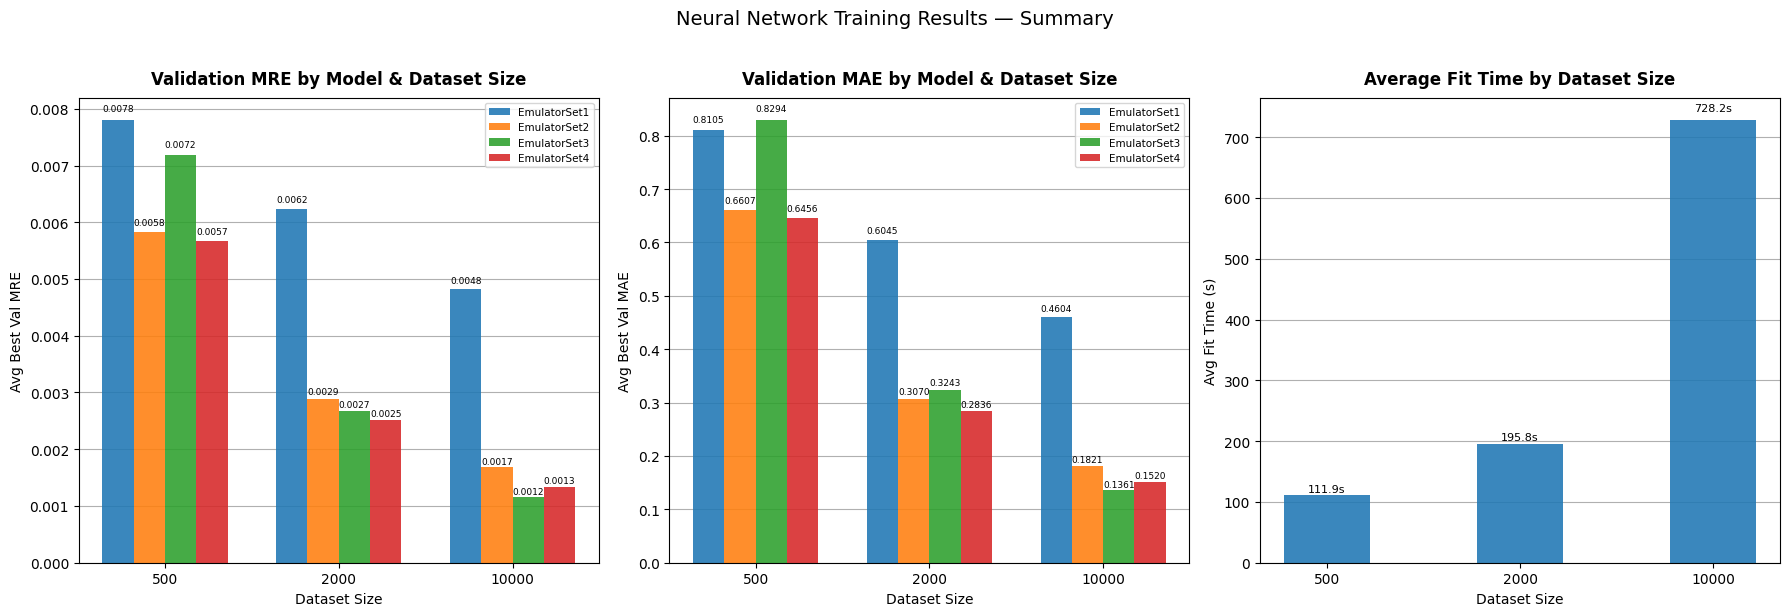


Figure saved to nn_saves/nn_results_analysis.png


In [57]:
# results csv analysis
results_df = pd.read_csv("nn_saves/nn_results.csv")
utils.show_fit_val_summary(results_df, save_path="nn_saves/nn_results_analysis.png")

In [58]:
utils.show_top_results(results_df, top_n=5)


Top 5 Results by Best Validation MRE:
                     experiment_id        model encoder scale_type  dataset_size   fit_time  best_epoch  best_train_loss  best_val_loss  best_train_mre  best_val_mre  best_train_mae  best_val_mae
  EmulatorSet3_single_minmax_10000 EmulatorSet3  single     minmax         10000 793.746402          96         0.002185       0.002164        0.000950      0.000969        0.111073      0.111109
EmulatorSet4_single_standard_10000 EmulatorSet4  single   standard         10000 605.449314         100         0.019993       0.019780        0.001033      0.001071        0.129294      0.132132
   EmulatorSet3_multi_minmax_10000 EmulatorSet3   multi     minmax         10000 805.632896          98         0.002316       0.002294        0.001094      0.001115        0.121058      0.119053
EmulatorSet2_single_standard_10000 EmulatorSet2  single   standard         10000 580.186641          98         0.019770       0.019546        0.001122      0.001143        0.13

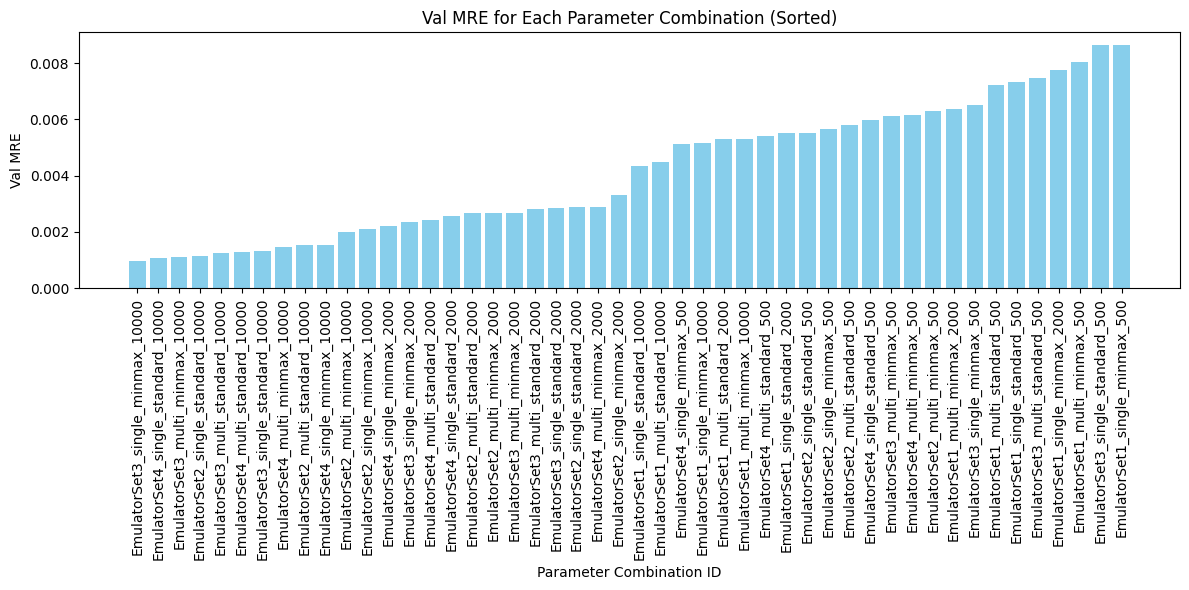


Bar plot saved to nn_saves/nn_results_barplot.png


In [59]:
utils.show_barplot_results(results_df, save_path="nn_saves/nn_results_barplot.png")

In [60]:
# chosen model row load
# chosen_model = results_df.loc[results_df["best_val_mre"].idxmin()]
chosen_model = results_df.loc[results_df["experiment_id"] == "EmulatorSet1_single_standard_10000"].iloc[0]
print(chosen_model)

experiment_id      EmulatorSet1_single_standard_10000
model                                    EmulatorSet1
encoder                                        single
scale_type                                   standard
dataset_size                                    10000
fit_time                                   921.296913
best_epoch                                        100
best_train_loss                              0.027664
best_val_loss                                0.027324
best_train_mre                               0.007093
best_val_mre                                  0.00433
best_train_mae                               0.395645
best_val_mae                                 0.387854
Name: 33, dtype: object


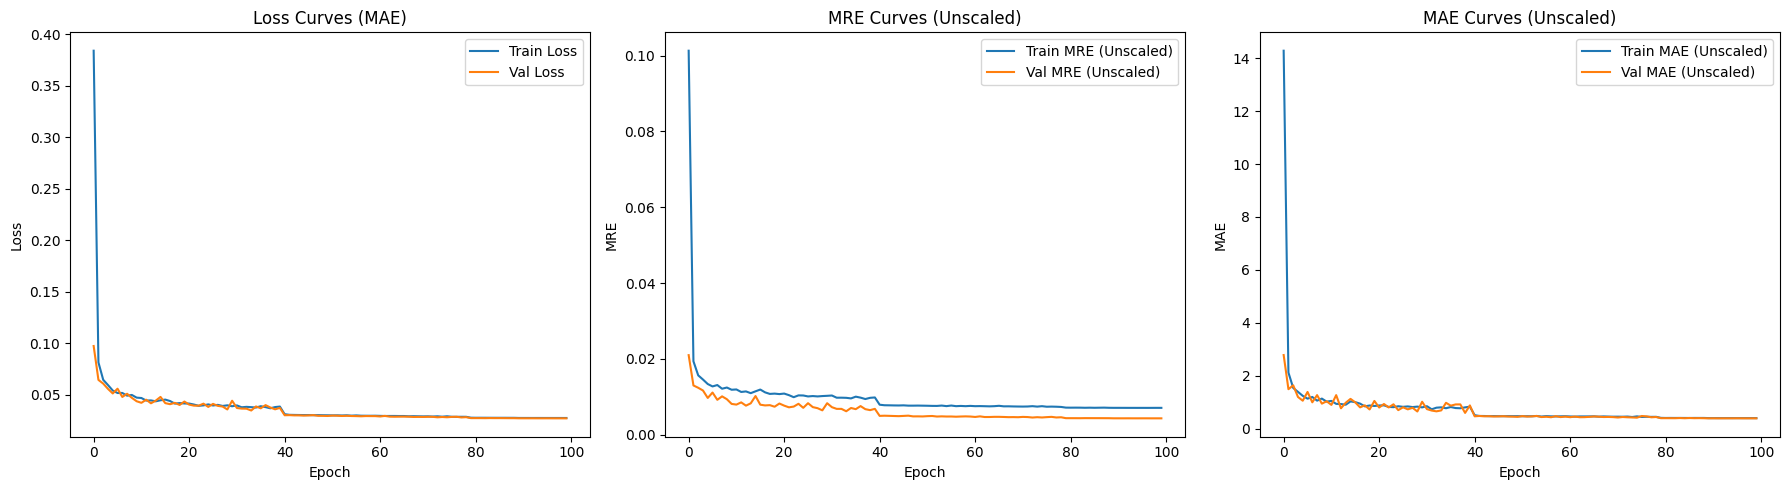

In [ ]:
# history load
with open(f"nn_saves/model_saves/{chosen_model['experiment_id']}_history.pkl", "rb") as f:
    history = pickle.load(f)

# history plotting
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curves (MAE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history["train_mre"], label="Train MRE (Unscaled)")
plt.plot(history["val_mre"], label="Val MRE (Unscaled)")
plt.title("MRE Curves (Unscaled)")
plt.xlabel("Epoch")
plt.ylabel("MRE")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history["train_mae"], label="Train MAE (Unscaled)")
plt.plot(history["val_mae"], label="Val MAE (Unscaled)")
plt.title("MAE Curves (Unscaled)")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

#### External Testing

For both MRE and MAE:
<ul>
    <li>Global average metric.</li>
    <li>Metric for each function.</li>
    <li>Metric for each wavelength.</li>
    <li>Metric for each function and for each wavelength.</li>
</ul>

In [87]:
# load best model
model = ARCHITECTURES[chosen_model["model"]](encoder_type=chosen_model["encoder"]).to(device)
model.load_state_dict(torch.load(f"nn_saves/model_saves/{chosen_model['experiment_id']}.pth", map_location=device))

if chosen_model["model"] in FULL_DS_MODELS:
    test_ds = config["test_ds_scaled"][chosen_model["scale_type"]]
    y_scalers = config["y_scalers"][chosen_model["scale_type"]]
    pca_list = None
else:
    test_ds = config["test_ds_reduced_scaled"][chosen_model["scale_type"]]
    y_scalers = config["y_scalers_reduced"][chosen_model["scale_type"]]
    pca_list = config["pca_lists"][chosen_model["scale_type"]]

In [88]:
# predict on test set for other metrics and visualization
X_test_tensor = torch.tensor(
    config["x_scalers"][chosen_model["scale_type"]].transform(X_test),
    dtype=torch.float32
).to(device)

is_scaled  = y_scalers is not None
is_reduced = pca_list  is not None
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_tensor)
    if is_scaled or is_reduced:
        y_pred_og_shape = torch.zeros((y_pred_test.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=y_pred_test.device)
        for i in range(globals.N_FUNCTIONS):
            y_pred_restored = y_pred_test[:, i, :].cpu().detach().numpy()
            if is_scaled:
                y_pred_restored = y_scalers[i].inverse_transform(y_pred_restored)
            if is_reduced:
                y_pred_restored = pca_list[i].inverse_transform(y_pred_restored)
            y_pred_og_shape[:, i, :] = torch.from_numpy(y_pred_restored).to(y_pred_test.device)
        y_pred_test = y_pred_og_shape

y_pred_test_np = y_pred_test.cpu().numpy()

Testing MRE: 0.010576789
Path Radiance MRE: 0.0155
Direct Solar Irradiance MRE: 0.0060
Diffuse Solar Irradiance MRE: 0.0103
Spherical Albedo MRE: 0.0131
Direct Transmittance MRE: 0.0042
Diffuse Transmittance MRE: 0.0144


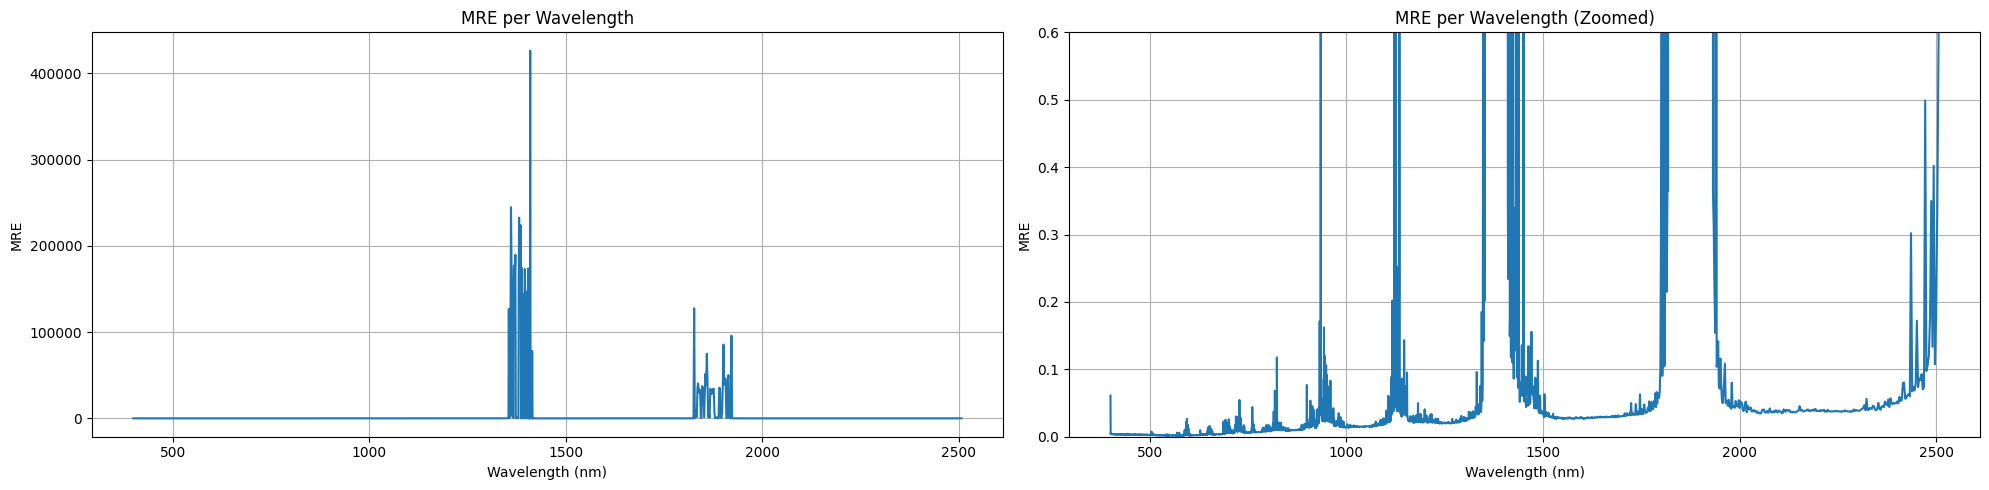

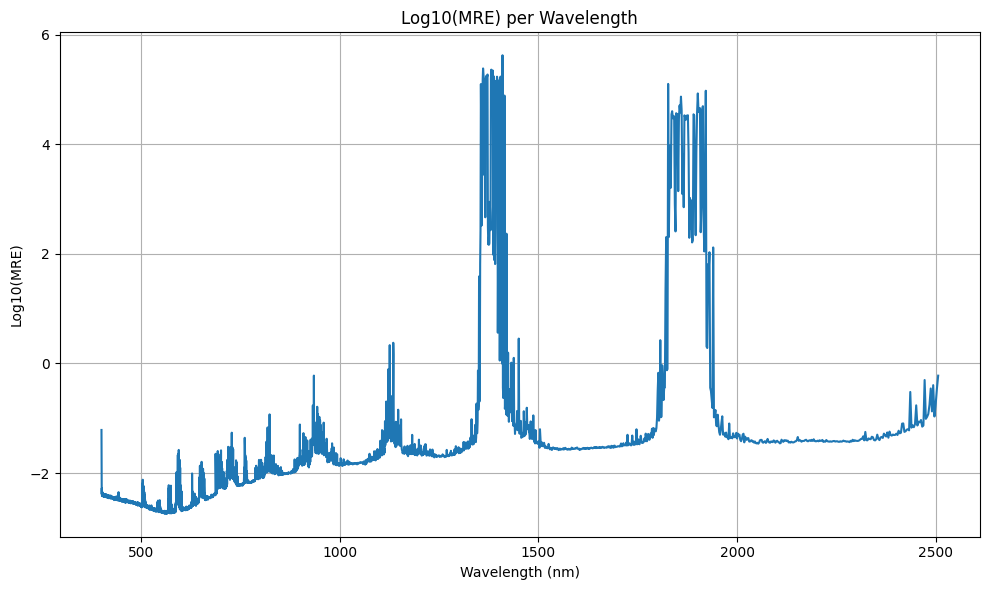

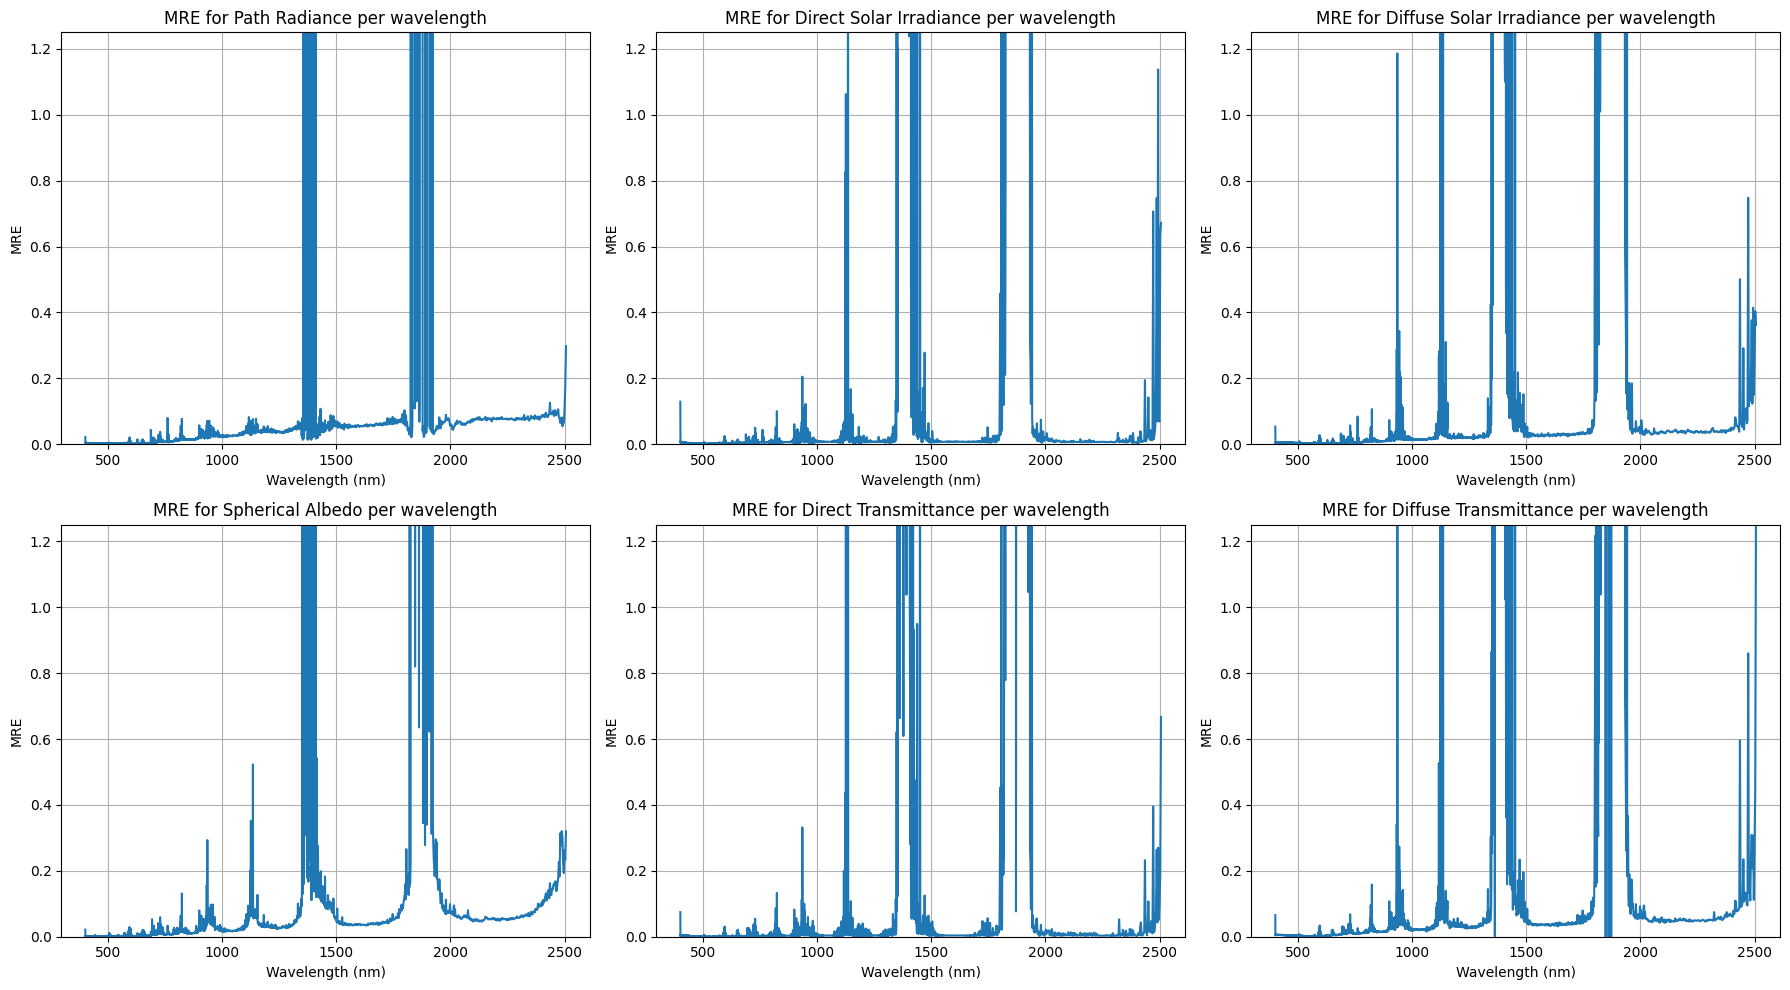

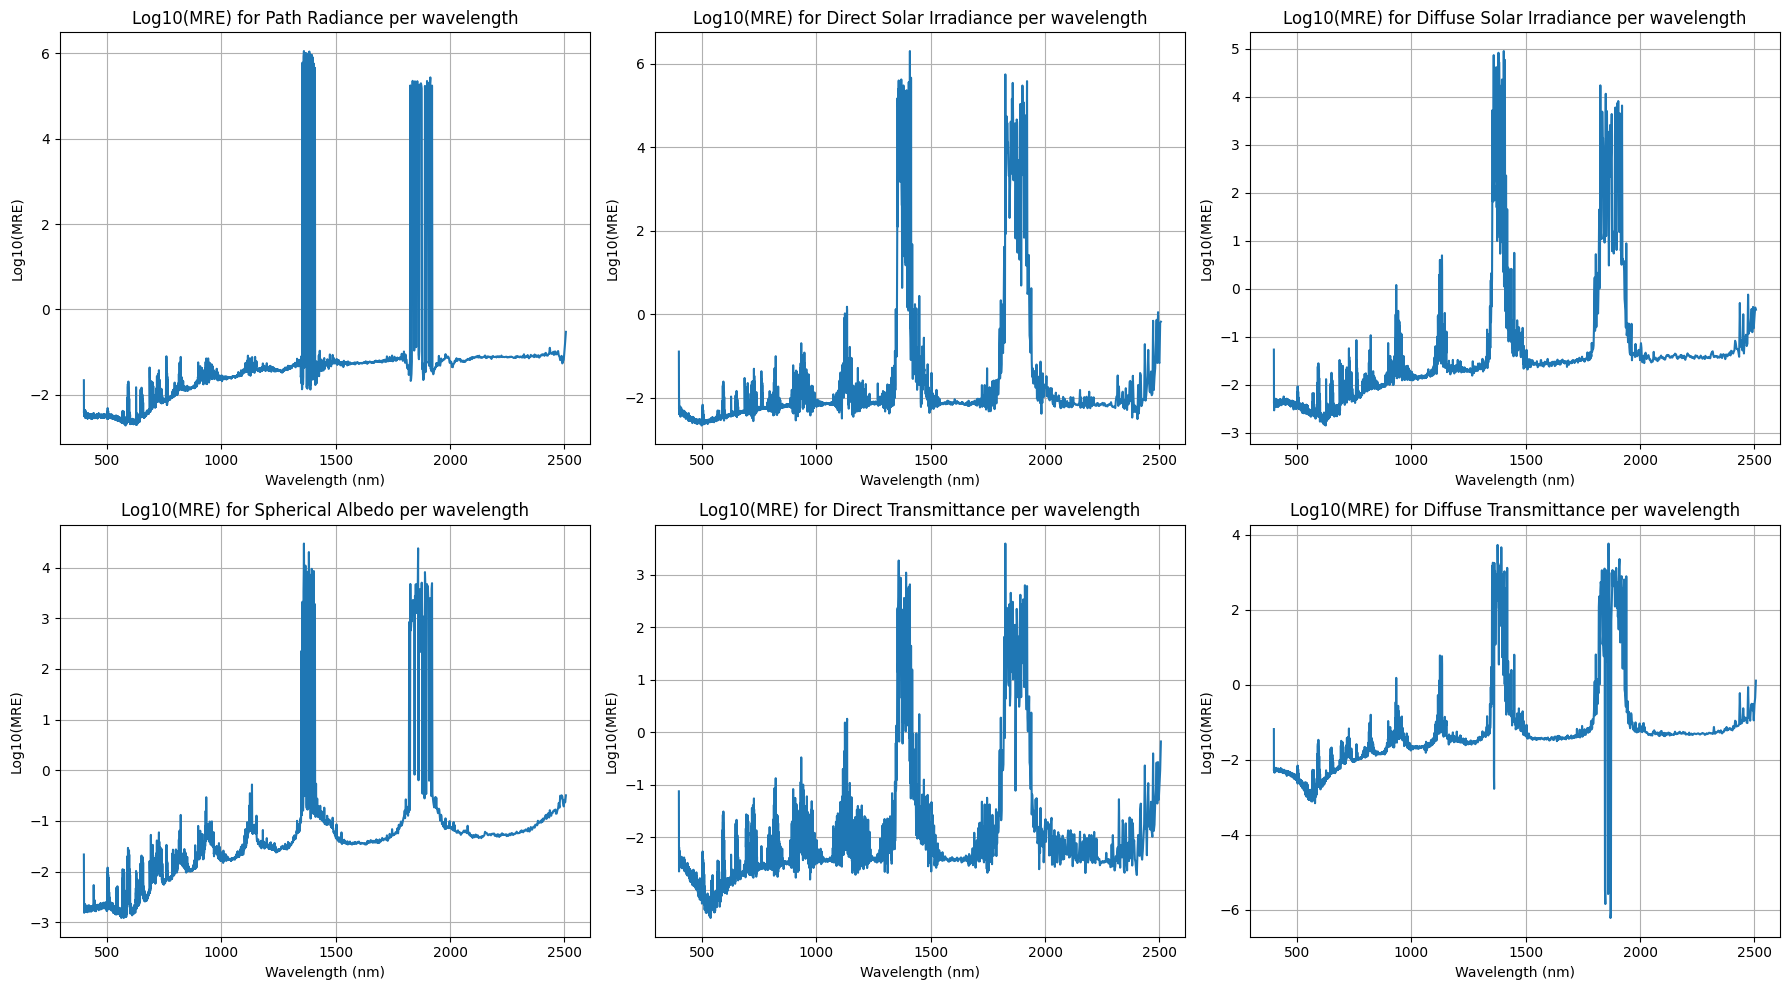

In [89]:
utils.show_test_results_mre(Y_test, y_pred_test_np, wavelengths)

Testing MAE: 0.8362117
Path Radiance MAE: 0.0908
Direct Solar Irradiance MAE: 3.6429
Diffuse Solar Irradiance MAE: 1.2786
Spherical Albedo MAE: 0.0007
Direct Transmittance MAE: 0.0027
Diffuse Transmittance MAE: 0.0015


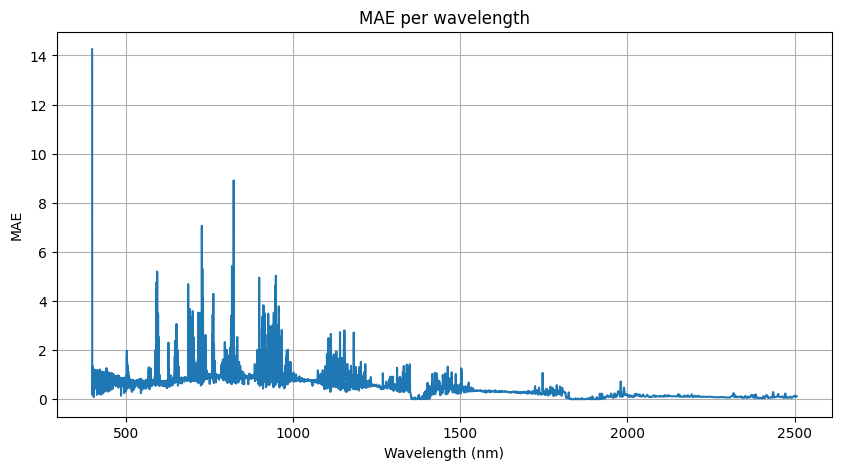

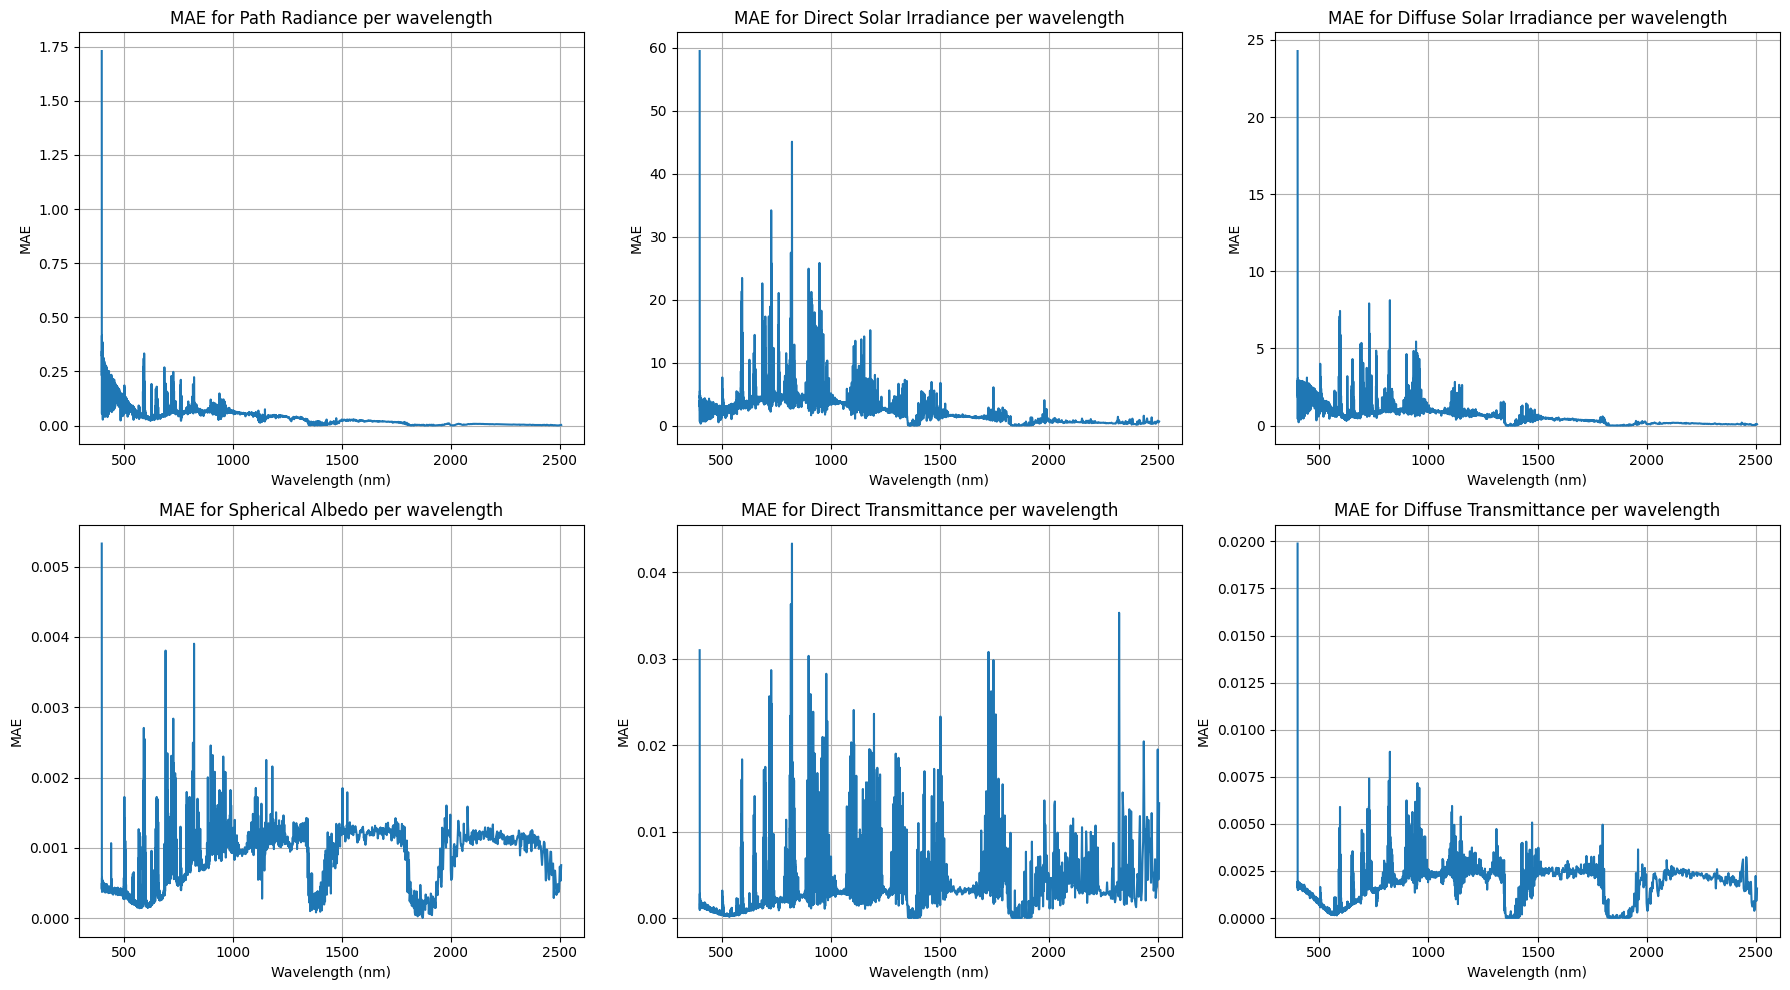

In [90]:
utils.show_test_results_mae(Y_test, y_pred_test_np, wavelengths)

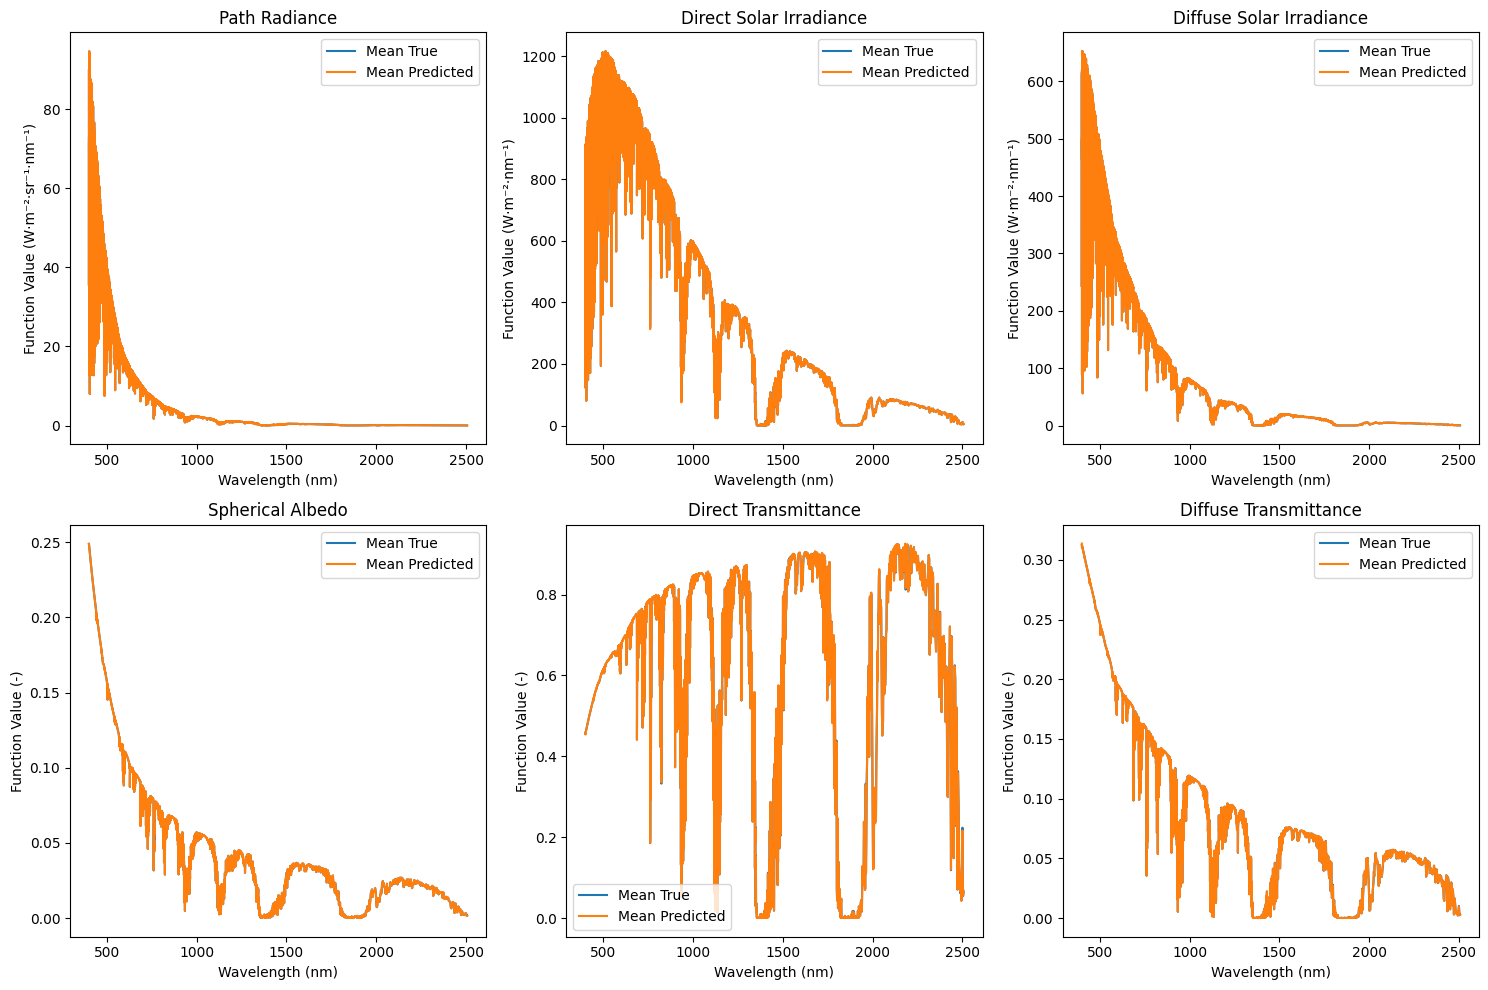

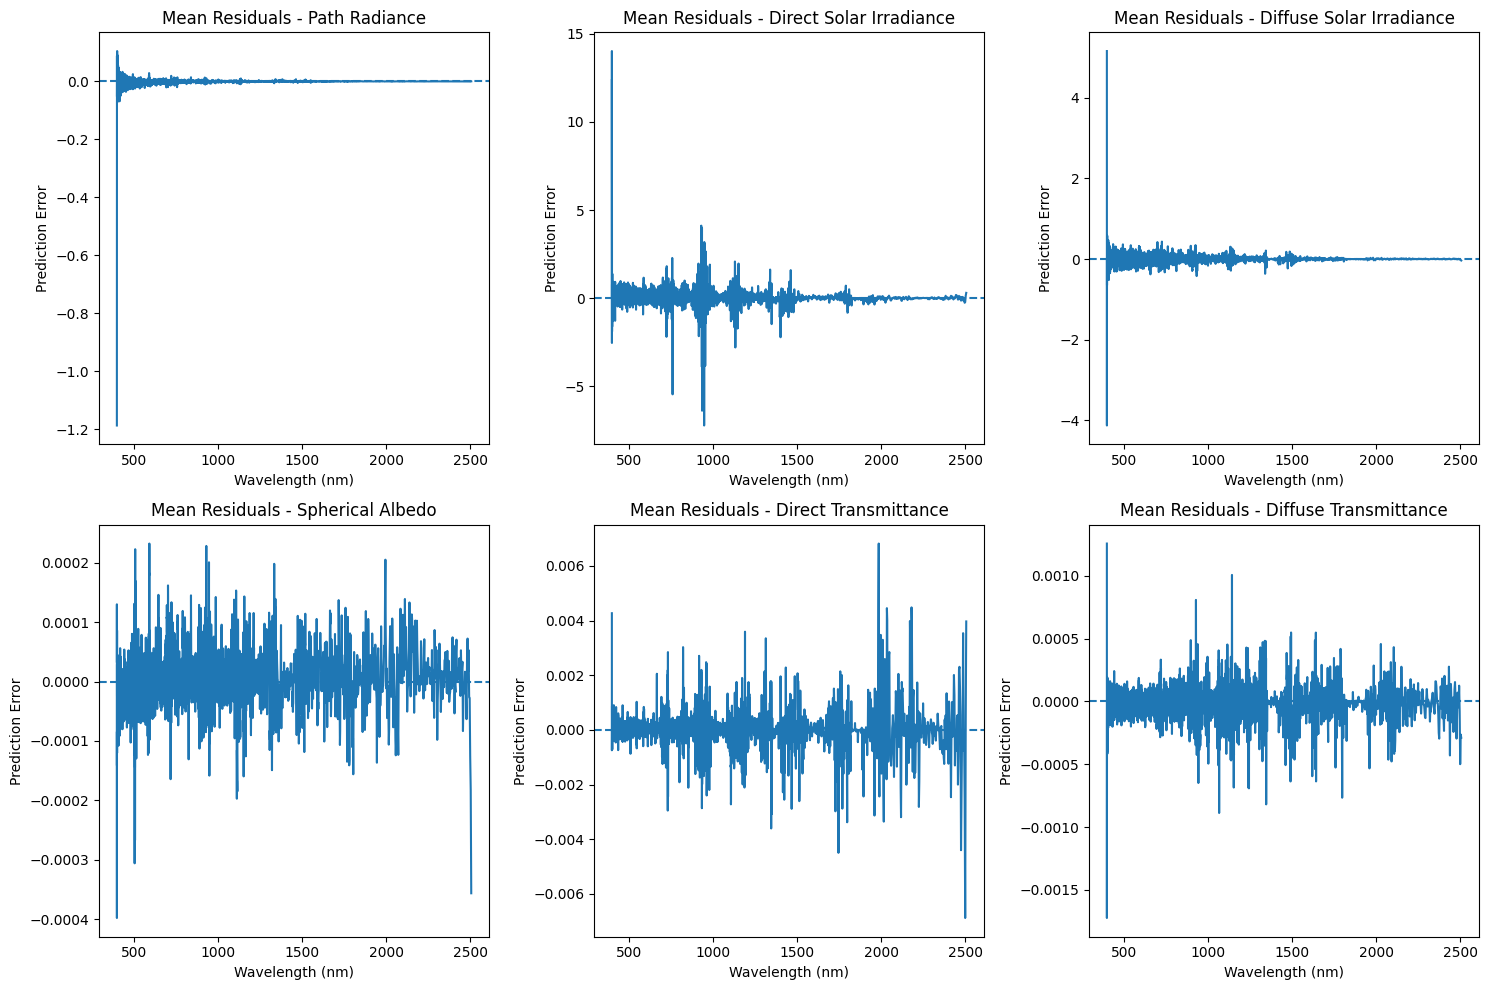

In [17]:
plt.figure(figsize=(15, 10))
for i in range(globals.N_FUNCTIONS):  # iterate over functions
    plt.subplot(2, 3, i + 1)
    plt.plot(wavelengths, np.mean(Y_test[:, i, :], axis=0), label="Mean True")
    plt.plot(wavelengths, np.mean(y_pred_test_np[:, i, :], axis=0), label="Mean Predicted")
    plt.title(f"{globals.function_names_plots[i]}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Function Value (" + globals.function_units_plots[i] + ")")
    plt.legend()

plt.tight_layout()
plt.show()

# --- residuals for all samples ---
residuals = y_pred_test_np - Y_test

# mean residual across samples
mean_residuals = np.mean(residuals, axis=0)  # shape: (6, 4205)

plt.figure(figsize=(15, 10))

for i in range(globals.N_FUNCTIONS):
    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, mean_residuals[i])
    plt.axhline(0, linestyle="--")

    plt.title(f"Mean Residuals - {globals.function_names_plots[i]}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Prediction Error")

plt.tight_layout()
plt.show()

Load the test csv and apply the model to measure inference runtime.

In [ ]:
X_test_csv = utils.load_test_csv(globals.CURRENT_TEST_FILE)
print(f"Test inputs from CSV shape: {X_test_csv.shape}")

is_scaled  = y_scalers is not None
is_reduced = pca_list  is not None
model.eval()

start_time_test_csv = time.time()

# scale test inputs with the same scaler used for training
X_test_csv_scaled = config["x_scalers"][chosen_model["scale_type"]].transform(X_test_csv)

X_test_tensor = torch.tensor(X_test_csv_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    y_pred_test = model(X_test_tensor)
    if is_scaled or is_reduced:
        y_pred_og_shape = torch.zeros((y_pred_test.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=y_pred_test.device)
        for i in range(globals.N_FUNCTIONS):
            y_pred_restored = y_pred_test[:, i, :].cpu().detach().numpy()
            if is_scaled:
                y_pred_restored = y_scalers[i].inverse_transform(y_pred_restored)
            if is_reduced:
                y_pred_restored = pca_list[i].inverse_transform(y_pred_restored)
            y_pred_og_shape[:, i, :] = torch.from_numpy(y_pred_restored).to(y_pred_test.device)
        y_pred_test = y_pred_og_shape
end_time_test_csv = time.time()

y_pred_test_np = y_pred_test.cpu().numpy()

print(f"Time taken to predict on test CSV: {end_time_test_csv - start_time_test_csv:.2f} seconds")
print("Predictions on test CSV shape:", y_pred_test_np.shape)

Test inputs from CSV shape: (10000, 9)
Time taken to predict on test CSV: 4.29 seconds
Predictions on test CSV shape: (10000, 6, 4205)


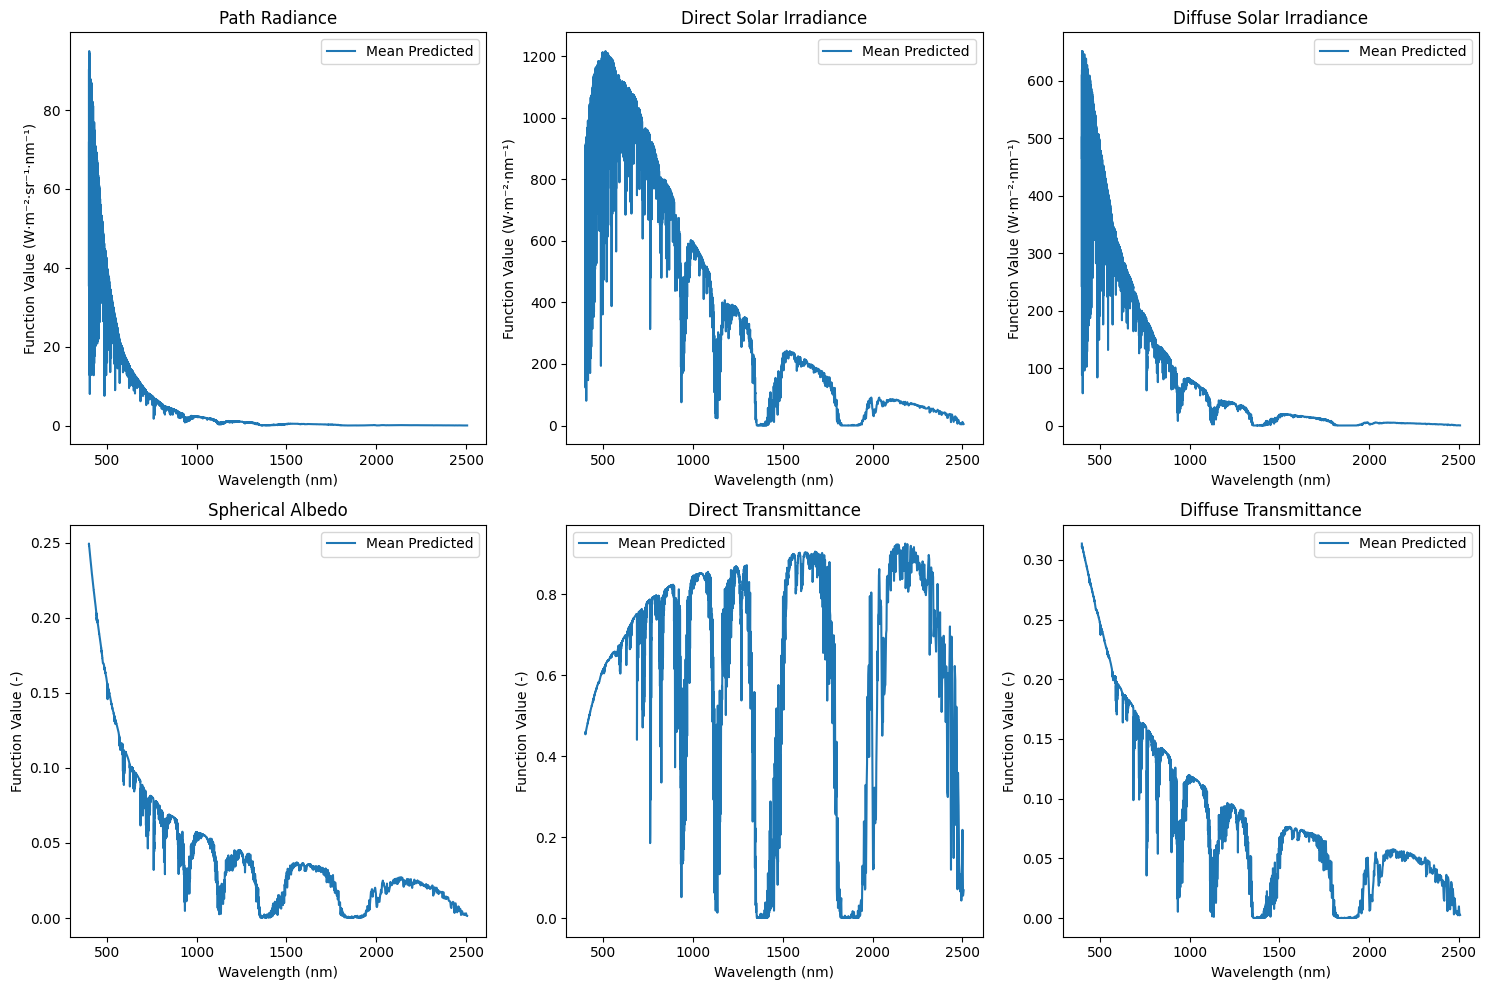

In [19]:
plt.figure(figsize=(15, 10))
for i in range(globals.N_FUNCTIONS):  # iterate over functions
    plt.subplot(2, 3, i + 1)
    plt.plot(wavelengths, np.mean(y_pred_test_np[:, i, :], axis=0), label="Mean Predicted")
    plt.title(f"{globals.function_names_plots[i]}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Function Value (" + globals.function_units_plots[i] + ")")
    plt.legend()

plt.tight_layout()
plt.show()